In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from getpass import getpass

print("All libraries imported successfully")

All libraries imported successfully


In [1]:
import mysql.connector

print("mysql.connector imported successfully")

mysql.connector imported successfully


In [1]:
import mysql.connector
from getpass import getpass

password = getpass("Enter MySQL password: ")

print("Attempting MySQL connection...")

connection = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password=password,
    database="ProcurementAnalytics",
    connection_timeout=10
)

print("MySQL connected successfully!")

Attempting MySQL connection...


ProgrammingError: 1045 (28000): Access denied for user 'root'@'localhost' (using password: NO)

In [ ]:
cursor = connection.cursor()

cursor.execute("SELECT DATABASE()")

result = cursor.fetchone()

print("Connected database:", result[0])

Connected database: procurementanalytics


In [ ]:
cursor.execute("""
    SELECT COUNT(*)
    FROM vw_procurement_spend
""")

result = cursor.fetchone()

print("Rows in vw_procurement_spend:", result[0])

Rows in vw_procurement_spend: 8724


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
query = """
SELECT *
FROM vw_procurement_spend
"""

procurement_df = pd.read_sql(
    query,
    connection
)

print("Data loaded successfully!")
print("Rows:", procurement_df.shape[0])
print("Columns:", procurement_df.shape[1])

C:\Users\Aditya\AppData\Local\Temp\ipykernel_21060\3605556296.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  procurement_df = pd.read_sql(


Data loaded successfully!
Rows: 8724
Columns: 22


In [ ]:
procurement_df.head()
procurement_df.tail()

,po_item_id,po_id,po_date,required_date,buyer_id,po_status,supplier_id,supplier_name,city,state,...,category_id,category_name,contract_id,quantity,unit_price,line_spend,promised_delivery_date,actual_delivery_date,received_qty,rejected_qty
8719,POITEM0007636,PO002190,2026-09-06,2026-10-01,BUY006,Cancelled,SUP0092,"Mital, Shankar and Mutti",Hyderabad,Delhi,...,CAT004,Industrial Equipment,CON0095,66,93770.63,6188861.58,2026-10-01,2026-10-07,60,0
8720,POITEM0007839,PO002252,2026-09-06,2026-09-13,BUY001,Approved,SUP0038,"Yadav, Loke and Oak",Bengaluru,Gujarat,...,CAT004,Industrial Equipment,CON0044,50,101443.61,5072180.50,2026-09-13,2026-09-28,47,1
8721,POITEM0008003,PO002301,2026-09-06,2026-10-08,BUY017,Approved,SUP0024,"Nair, Bhalla and Karnik",Noida,Telangana,...,CAT004,Industrial Equipment,NaN,41,88808.31,3641140.71,2026-10-08,2026-10-13,38,0
8722,POITEM0008435,PO002418,2026-09-06,2026-09-15,BUY004,Approved,SUP0067,"Bhagat, Chaudhari and Bhat",Hyderabad,Karnataka,...,CAT004,Industrial Equipment,NaN,89,104286.69,9281515.41,2026-09-15,2026-10-09,82,6
8723,POITEM0008664,PO002483,2026-09-06,2026-09-19,BUY005,Approved,SUP0086,"Bir, Keer and Raval",Bengaluru,Telangana,...,CAT004,Industrial Equipment,CON0070,85,88009.53,7480810.05,2026-09-19,2026-10-08,78,4


In [ ]:
print(procurement_df.columns.tolist())

['po_item_id', 'po_id', 'po_date', 'required_date', 'buyer_id', 'po_status', 'supplier_id', 'supplier_name', 'city', 'state', 'product_id', 'product_name', 'category_id', 'category_name', 'contract_id', 'quantity', 'unit_price', 'line_spend', 'promised_delivery_date', 'actual_delivery_date', 'received_qty', 'rejected_qty']


In [ ]:
procurement_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8724 entries, 0 to 8723
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   po_item_id              8724 non-null   str    
 1   po_id                   8724 non-null   str    
 2   po_date                 8724 non-null   object 
 3   required_date           8724 non-null   object 
 4   buyer_id                8724 non-null   str    
 5   po_status               8724 non-null   str    
 6   supplier_id             8724 non-null   str    
 7   supplier_name           8724 non-null   str    
 8   city                    8724 non-null   str    
 9   state                   8724 non-null   str    
 10  product_id              8724 non-null   str    
 11  product_name            8724 non-null   str    
 12  category_id             8724 non-null   str    
 13  category_name           8724 non-null   str    
 14  contract_id             5280 non-null   str    
 15

In [ ]:
procurement_df.describe()

,quantity,unit_price,line_spend,received_qty,rejected_qty
count,8724.000000,8724.000000,8.724000e+03,8724.000000,8724.000000
mean,50.266506,77901.944559,3.931942e+06,47.200940,1.547226
std,28.935177,46795.436862,3.558623e+06,27.571949,1.703909
min,1.000000,739.880000,1.678000e+03,0.000000,0.000000
25%,25.000000,39159.702500,1.033547e+06,23.000000,0.000000
50%,50.000000,78623.910000,2.872261e+06,47.000000,1.000000
75%,75.000000,115172.035000,6.039759e+06,71.000000,2.000000
max,100.000000,343021.540000,2.366849e+07,99.000000,10.000000


In [ ]:
missing = procurement_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

contract_id             3444
actual_delivery_date      30
dtype: int64


In [ ]:
print("Duplicate rows:", procurement_df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("PO date range:")
print("Minimum:", procurement_df["po_date"].min())
print("Maximum:", procurement_df["po_date"].max())

PO date range:
Minimum: 2026-09-06
Maximum: 2026-09-07


In [ ]:
# Calculate KPIs

total_spend = procurement_df["line_spend"].sum()

po_count = procurement_df["po_id"].nunique()

supplier_count = procurement_df["supplier_id"].nunique()

product_count = procurement_df["product_id"].nunique()


# Create summary table

summary = {
    "Total Spend (Crore)": round(total_spend / 10_000_000, 2),
    "Purchase Orders": po_count,
    "Suppliers": supplier_count,
    "Products": product_count
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Spend (Crore),3430.23
1,Purchase Orders,2500.00
2,Suppliers,100.00
3,Products,250.00


In [ ]:
supplier_spend = (
    procurement_df
    .groupby(["supplier_id", "supplier_name"], as_index=False)
    .agg(total_spend=("line_spend", "sum"))
    .sort_values("total_spend", ascending=False)
)

supplier_spend["spend_crore"] = (
    supplier_spend["total_spend"] / 10_000_000
).round(2)

supplier_spend.head(10)

,supplier_id,supplier_name,total_spend,spend_crore
95,SUP0096,Palla Inc,5.660788e+08,56.61
25,SUP0026,Bhatti-Kakar,5.275191e+08,52.75
48,SUP0049,"Sunder, Biswas and Walia",4.951278e+08,49.51
63,SUP0064,Gupta-Chandra,4.935876e+08,49.36
94,SUP0095,Toor LLC,4.711857e+08,47.12
51,SUP0052,"Sampath, Kakar and Zacharia",4.542911e+08,45.43
54,SUP0055,Dara-Kota,4.497672e+08,44.98
8,SUP0009,"Sami, Oak and Mall",4.495363e+08,44.95
45,SUP0046,Choudhury LLC,4.489870e+08,44.90
56,SUP0057,Karpe PLC,4.489139e+08,44.89


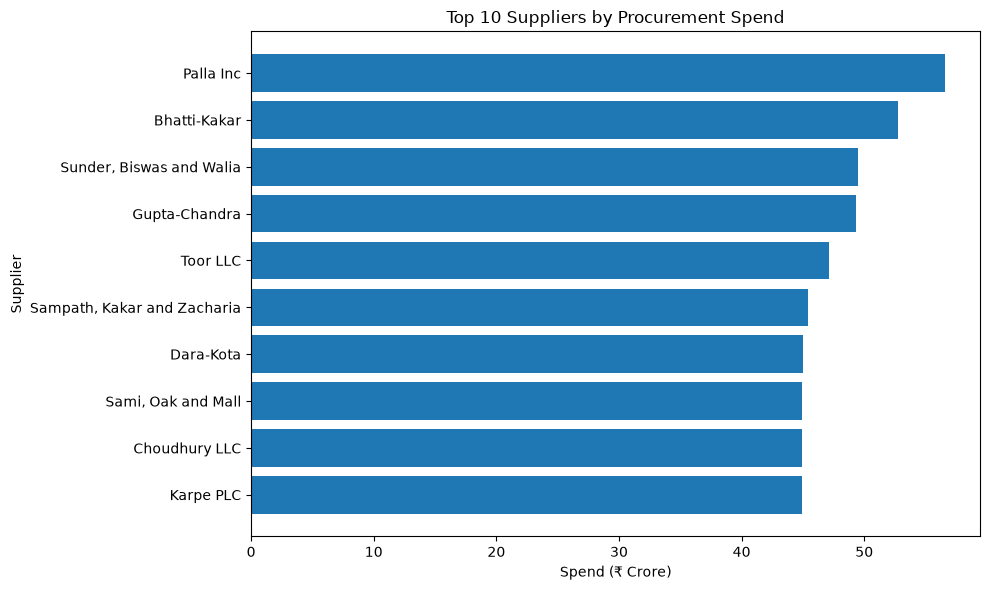

In [ ]:
top10 = supplier_spend.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["supplier_name"],
    top10["spend_crore"]
)

plt.xlabel("Spend (₹ Crore)")
plt.ylabel("Supplier")
plt.title("Top 10 Suppliers by Procurement Spend")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
category_spend = (
    procurement_df
    .groupby(["category_id", "category_name"], as_index=False)
    .agg(total_spend=("line_spend", "sum"))
    .sort_values("total_spend", ascending=False)
)

category_spend["spend_crore"] = (
    category_spend["total_spend"] / 10_000_000
).round(2)

category_spend["spend_percentage"] = (
    category_spend["total_spend"] / total_spend * 100
).round(2)

category_spend

,category_id,category_name,total_spend,spend_crore,spend_percentage
4,CAT005,Raw Materials,5.192098e+09,519.21,15.14
7,CAT008,Maintenance,4.549460e+09,454.95,13.26
9,CAT010,Facilities,4.479743e+09,447.97,13.06
6,CAT007,Logistics,3.303985e+09,330.40,9.63
8,CAT009,Professional Services,3.174992e+09,317.50,9.26
1,CAT002,Software & Licenses,2.818129e+09,281.81,8.22
5,CAT006,Packaging,2.802945e+09,280.29,8.17
3,CAT004,Industrial Equipment,2.798606e+09,279.86,8.16
2,CAT003,Office Supplies,2.591656e+09,259.17,7.56
0,CAT001,IT Hardware,2.590649e+09,259.06,7.55


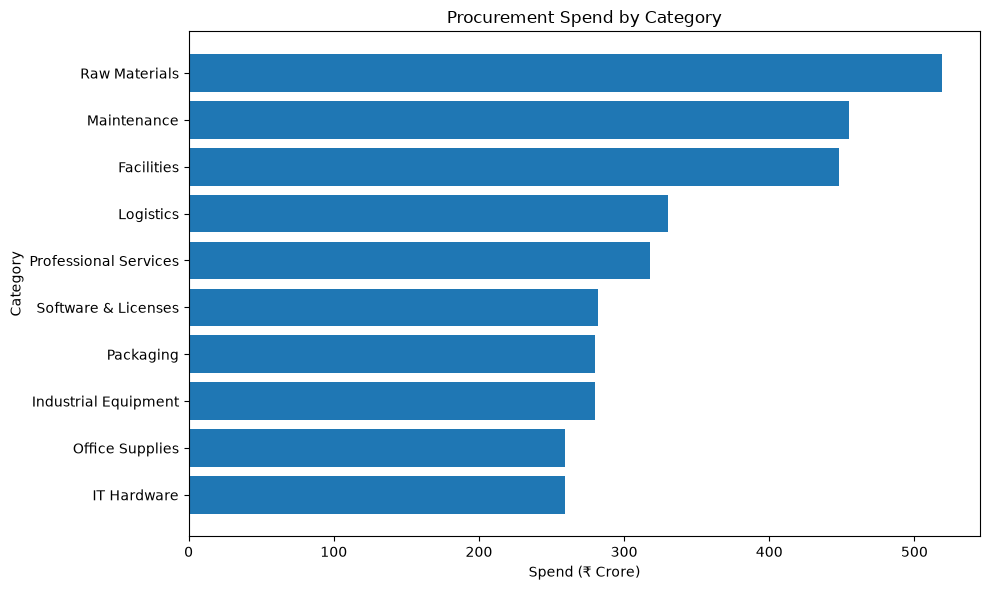

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    category_spend["category_name"],
    category_spend["spend_crore"]
)

plt.xlabel("Spend (₹ Crore)")
plt.ylabel("Category")
plt.title("Procurement Spend by Category")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Price recovery
price_query = """
SELECT *
FROM vw_price_variance
"""

price_df = pd.read_sql(
    price_query,
    connection
)

price_df.head()

C:\Users\Aditya\AppData\Local\Temp\ipykernel_21060\1579233779.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  price_df = pd.read_sql(


,po_item_id,po_id,product_id,product_name,base_unit_cost,quantity,unit_price,price_variance,price_variance_percentage,potential_savings
0,POITEM0000043,PO000012,PROD0001,Maintenance Service,4811.23,72,5308.52,497.29,10.34,35804.88
1,POITEM0000113,PO000033,PROD0001,Maintenance Service,4811.23,73,5195.11,383.88,7.98,28023.24
2,POITEM0000279,PO000076,PROD0001,Maintenance Service,4811.23,66,5565.99,754.76,15.69,49814.16
3,POITEM0000394,PO000114,PROD0001,Maintenance Service,4811.23,21,4258.64,-552.59,-11.49,0.00
4,POITEM0000471,PO000137,PROD0001,Maintenance Service,4811.23,56,5956.13,1144.90,23.80,64114.40


In [ ]:
# Total Potential Recoverey
potential_recovery = price_df["potential_savings"].sum()

print(
    "Potential Price Recovery:",
    round(potential_recovery / 10_000_000, 2),
    "Crore"
)

Potential Price Recovery: 260.19 Crore


In [ ]:
# Biggest Recovery Opportunities
recovery_by_product = (
    price_df
    .groupby("product_name", as_index=False)
    .agg(
        potential_savings=("potential_savings", "sum")
    )
    .sort_values("potential_savings", ascending=False)
)

recovery_by_product["recovery_crore"] = (
    recovery_by_product["potential_savings"] / 10_000_000
).round(2)

recovery_by_product.head(10)

,product_name,potential_savings,recovery_crore
11,Network Switch,1.898323e+08,18.98
14,Printer,1.820471e+08,18.20
9,Monitor,1.645053e+08,16.45
1,Cleaning Service,1.604326e+08,16.04
0,Cardboard Box,1.526437e+08,15.26
12,Office Chair,1.464736e+08,14.65
13,Plastic Packaging,1.427600e+08,14.28
10,Mouse,1.395689e+08,13.96
3,Copper Wire,1.354609e+08,13.55
17,Software License,1.339852e+08,13.40


In [ ]:
# Monthly Procurement Spend
procurement_df["po_date"] = pd.to_datetime(
    procurement_df["po_date"]
)

procurement_df["month"] = (
    procurement_df["po_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_spend = (
    procurement_df
    .groupby("month", as_index=False)
    .agg(total_spend=("line_spend", "sum"))
)

monthly_spend["spend_crore"] = (
    monthly_spend["total_spend"] / 10_000_000
).round(2)

monthly_spend.head()

,month,total_spend,spend_crore
0,2026-09,3.430226e+10,3430.23


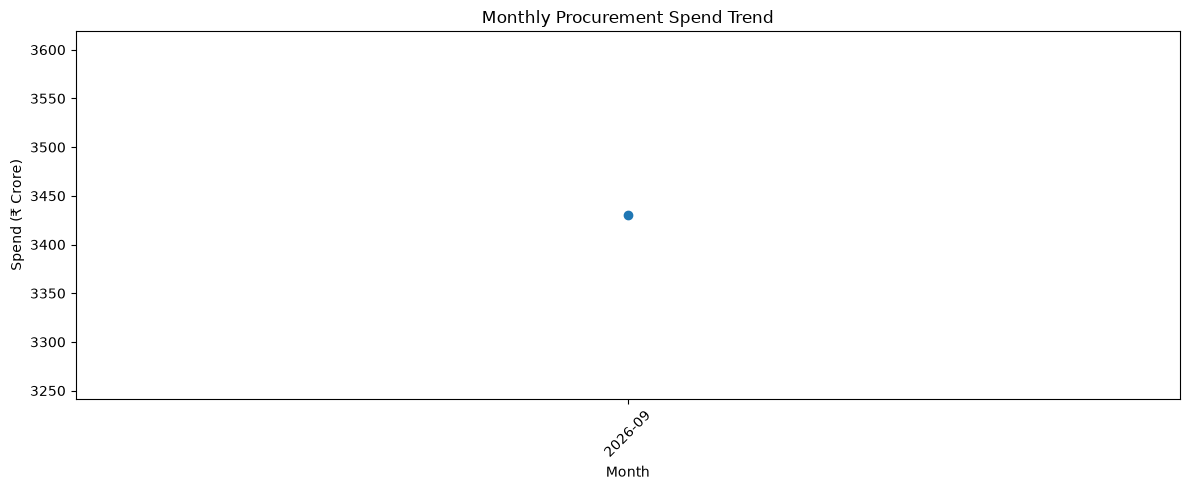

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_spend["month"],
    monthly_spend["spend_crore"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Spend (₹ Crore)")
plt.title("Monthly Procurement Spend Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# — Correlation Analysis with Seaborn
numeric_columns = [
    "quantity",
    "unit_price",
    "line_spend",
    "received_qty",
    "rejected_qty"
]

correlation = procurement_df[numeric_columns].corr()

correlation

,quantity,unit_price,line_spend,received_qty,rejected_qty
quantity,1.000000,0.011880,0.643354,0.998161,0.417630
unit_price,0.011880,1.000000,0.672521,0.011998,0.008741
line_spend,0.643354,0.672521,1.000000,0.642355,0.274446
received_qty,0.998161,0.011998,0.642355,1.000000,0.387228
rejected_qty,0.417630,0.008741,0.274446,0.387228,1.000000


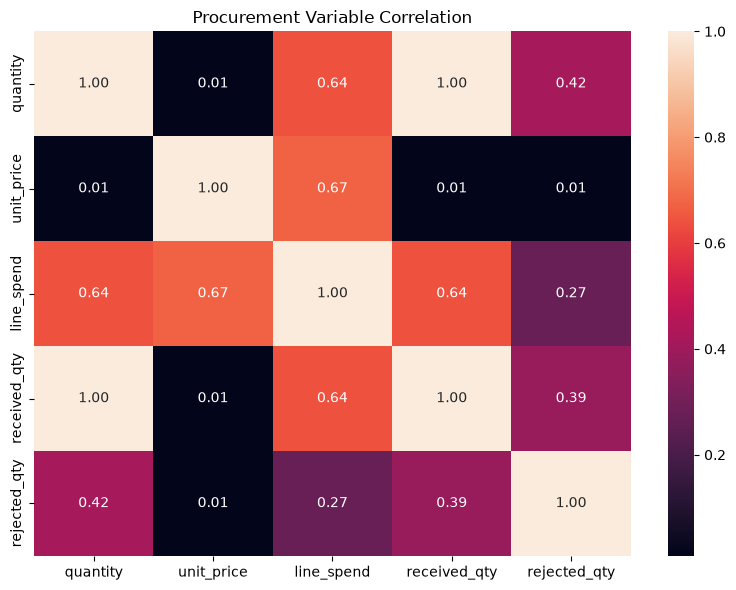

In [ ]:
# Heat Map
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Procurement Variable Correlation")

plt.tight_layout()
plt.show()

In [ ]:
# Outlier Detection with Scikit-learn
supplier_features = (
    procurement_df
    .groupby(["supplier_id", "supplier_name"], as_index=False)
    .agg(
        total_spend=("line_spend", "sum"),
        avg_unit_price=("unit_price", "mean"),
        total_quantity=("quantity", "sum"),
        total_rejected=("rejected_qty", "sum")
    )
)

supplier_features.head()

,supplier_id,supplier_name,total_spend,avg_unit_price,total_quantity,total_rejected
0,SUP0001,"Choudhury, Bakshi and Maharaj",3.545096e+08,79003.880222,4505,157
1,SUP0002,Kapoor and Sons,3.623668e+08,76337.891900,4958,165
2,SUP0003,"Chaudry, Chahal and Sami",3.201758e+08,81479.180633,3994,105
3,SUP0004,Balan Inc,3.168703e+08,77598.192278,4132,117
4,SUP0005,Kaul PLC,2.788284e+08,82643.465909,3632,97


In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
features = [
    "total_spend",
    "avg_unit_price",
    "total_quantity",
    "total_rejected"
]

X = supplier_features[features]

X.head()

,total_spend,avg_unit_price,total_quantity,total_rejected
0,3.545096e+08,79003.880222,4505,157
1,3.623668e+08,76337.891900,4958,165
2,3.201758e+08,81479.180633,3994,105
3,3.168703e+08,77598.192278,4132,117
4,2.788284e+08,82643.465909,3632,97


In [ ]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

supplier_features["outlier"] = model.fit_predict(X)

In [ ]:
supplier_features["outlier"].value_counts()

outlier
 1    95
-1     5
Name: count, dtype: int64

In [ ]:
outliers = (
    supplier_features[
        supplier_features["outlier"] == -1
    ]
    .sort_values("total_spend", ascending=False)
)

outliers[
    [
        "supplier_id",
        "supplier_name",
        "total_spend",
        "avg_unit_price",
        "total_quantity",
        "total_rejected"
    ]
]

,supplier_id,supplier_name,total_spend,avg_unit_price,total_quantity,total_rejected
95,SUP0096,Palla Inc,5.660788e+08,73954.262727,7330,232
25,SUP0026,Bhatti-Kakar,5.275191e+08,93140.523235,5483,140
5,SUP0006,"Bala, Issac and Saini",3.789271e+08,66003.742054,5852,188
70,SUP0071,Mallick Group,2.129271e+08,98471.552955,2089,59
65,SUP0066,Roy-Sibal,8.783404e+07,76028.554688,1256,46


In [ ]:
#Supplier Segmentation
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("K-Means and StandardScaler imported successfully!")

K-Means and StandardScaler imported successfully!


In [ ]:
#Prepare Supplier Data
features = [
    "total_spend",
    "avg_unit_price",
    "total_quantity",
    "total_rejected"
]

In [ ]:
X = supplier_features[features]

X.head()

,total_spend,avg_unit_price,total_quantity,total_rejected
0,3.545096e+08,79003.880222,4505,157
1,3.623668e+08,76337.891900,4958,165
2,3.201758e+08,81479.180633,3994,105
3,3.168703e+08,77598.192278,4132,117
4,2.788284e+08,82643.465909,3632,97


In [ ]:
# K MEANS MODAL
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

supplier_features["supplier_segment"] = (
    kmeans.fit_predict(X_scaled)
)

In [ ]:
supplier_features[
    [
        "supplier_id",
        "supplier_name",
        "total_spend",
        "avg_unit_price",
        "total_quantity",
        "total_rejected",
        "supplier_segment"
    ]
].head(20)

,supplier_id,supplier_name,total_spend,avg_unit_price,total_quantity,total_rejected,supplier_segment
0,SUP0001,"Choudhury, Bakshi and Maharaj",3.545096e+08,79003.880222,4505,157,1
1,SUP0002,Kapoor and Sons,3.623668e+08,76337.891900,4958,165,3
2,SUP0003,"Chaudry, Chahal and Sami",3.201758e+08,81479.180633,3994,105,2
3,SUP0004,Balan Inc,3.168703e+08,77598.192278,4132,117,0
4,SUP0005,Kaul PLC,2.788284e+08,82643.465909,3632,97,2
5,SUP0006,"Bala, Issac and Saini",3.789271e+08,66003.742054,5852,188,3
6,SUP0007,Sen PLC,3.116794e+08,74660.941111,3873,125,0
7,SUP0008,Ahuja-Dutta,2.970527e+08,73976.547407,4260,135,0
8,SUP0009,"Sami, Oak and Mall",4.495363e+08,80778.005238,5597,158,3
9,SUP0010,Kale LLC,2.630826e+08,74047.621875,3562,121,0


In [ ]:
segment_summary = (
    supplier_features
    .groupby("supplier_segment")
    .agg(
        suppliers=("supplier_id", "count"),
        avg_spend=("total_spend", "mean"),
        avg_unit_price=("avg_unit_price", "mean"),
        avg_quantity=("total_quantity", "mean"),
        avg_rejected=("total_rejected", "mean")
    )
    .round(2)
)

segment_summary

,suppliers,avg_spend,avg_unit_price,avg_quantity,avg_rejected
supplier_segment,,,,,
0,30,3.071003e+08,73984.29,4165.70,124.07
1,25,3.785955e+08,82292.28,4543.64,144.92
2,22,2.557772e+08,81002.13,3161.73,97.14
3,23,4.346638e+08,76231.91,5669.78,174.61


In [ ]:
# ## 11. Key Findings

# - Total procurement spend was approximately ₹3,430.23 crore.
# - Procurement spend was concentrated among a relatively small group of suppliers.
# - Non-contract procurement represented approximately 39.27% of spend.
# - The overall late-delivery rate was approximately 80.19%.
# - The overall rejection rate was approximately 3.19%.
# - The analysis identified approximately ₹260.19 crore in modeled potential price-recovery opportunities.
# - Invoice-to-PO validation was used to identify invoice amount mismatches.
# - Isolation Forest was applied to identify potentially anomalous invoice transactions.
# - K-Means clustering was used to segment suppliers based on procurement characteristics.

# > Note: The dataset is synthetic and the recovery figures represent modeled opportunities requiring commercial validation.